# Task 5: Customer Purchase Prediction
### Predict if a user will buy based on website visit, ad click, and demo watch

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings; warnings.filterwarnings("ignore")


In [2]:
np.random.seed(7)
n = 30
visited = np.random.choice([0,1], n, p=[0.4,0.6])
clicked = np.random.choice([0,1], n, p=[0.5,0.5])
watched = np.random.choice([0,1], n, p=[0.55,0.45])
bought  = ((visited + clicked + watched) >= 2).astype(int)

df = pd.DataFrame({
    "visited_website": visited,
    "clicked_ad":      clicked,
    "watched_demo":    watched,
    "will_buy":        bought
})
df["buy_label"] = df["will_buy"].map({1:"Buy", 0:"Not Buy"})
print(df.to_string(index=False))
print("\nPurchase Distribution:")
print(df["buy_label"].value_counts())


 visited_website  clicked_ad  watched_demo  will_buy buy_label
               0           0             1         0   Not Buy
               1           0             1         1       Buy
               1           0             0         0   Not Buy
               1           0             0         0   Not Buy
               1           0             1         1       Buy
               1           1             0         1       Buy
               1           1             1         1       Buy
               0           0             1         0   Not Buy
               0           1             1         1       Buy
               1           0             0         0   Not Buy
               1           0             1         1       Buy
               1           0             0         0   Not Buy
               0           1             0         0   Not Buy
               0           0             0         0   Not Buy
               0           0             1         0   

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["buy_label"].value_counts().plot(kind="pie", autopct="%1.1f%%", ax=axes[0],
    colors=["#2ecc71","#e74c3c"], startangle=90)
axes[0].set_title("Purchase Distribution", fontweight="bold"); axes[0].set_ylabel("")

corr_data = df[["visited_website","clicked_ad","watched_demo","will_buy"]].corr()
sns.heatmap(corr_data, annot=True, cmap="coolwarm", ax=axes[1], fmt=".2f")
axes[1].set_title("Feature Correlation", fontweight="bold")
plt.tight_layout(); plt.savefig("task5_viz.png", dpi=100); plt.show()


 Accuracy: 62.5 %

 Classification Report:
              precision    recall  f1-score   support

     Not Buy       0.25      1.00      0.40         1
         Buy       1.00      0.57      0.73         7

    accuracy                           0.62         8
   macro avg       0.62      0.79      0.56         8
weighted avg       0.91      0.62      0.69         8



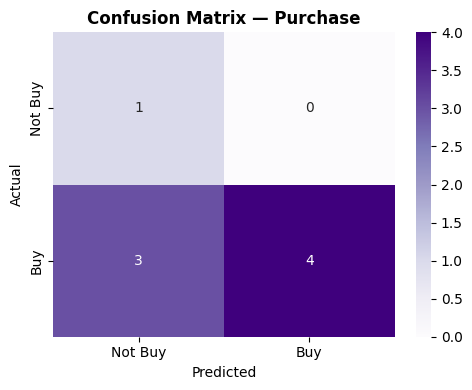

In [4]:
X = df[["visited_website","clicked_ad","watched_demo"]]
y = df["will_buy"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

#use navbias model for classification
# from sklearn.naive_bayes import MultinomialNB
# model = MultinomialNB()
# model.fit(X_train, y_train)
# y_pred = model.predict(X_test)

print(" Accuracy:", round(accuracy_score(y_test, y_pred)*100, 2), "%")
print("\n Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Not Buy","Buy"]))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples",
            xticklabels=["Not Buy","Buy"], yticklabels=["Not Buy","Buy"])
plt.title("Confusion Matrix — Purchase", fontweight="bold")
plt.ylabel("Actual"); plt.xlabel("Predicted")
plt.tight_layout(); plt.savefig("task5_cm.png", dpi=100); plt.show()
